# Model 5: Gradient Boosting: Coral Reef Regime Classification

Reproduces the **Gradient Boosted Trees with engineered features** (paper: train 0.83 / val 0.69) from *"Predicting Coral Reef Regimes from Human and Natural Influences"* (Walecka, Murphy, Cheng, CS 229).

**Protocol (same as the other models):**
- Fixed 80/20 split → train+val = 496 rows, test = 124 rows (test used **once**, at the end)
- 5-fold CV on the 496 training rows for validation scores and tuning
- Metric: micro-averaged F1 (plus macro-F1 and per-class recall)

**Contents**
1. Load data
2. Baseline: default gradient boosting, original vs. engineered features
3. Tuned search with 5-fold CV. The number of boosting rounds is chosen using *staged predictions*, so one fit scores every ensemble size
4. Learning curves over boosting rounds (the classic overfitting picture)
5. Feature importances (impurity and permutation)
6. One-shot test evaluation and error analysis
7. Summary against the paper and the other models

In [1]:
import os, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.inspection import permutation_importance
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                             classification_report, recall_score)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 229
CLASS_NAMES = ["Reg 1", "Reg 2", "Reg 3", "Reg 5"]

## 1. Load data
The repo ships imputed ("complete") data, the 5 engineered features, and a fixed split. The authors' 100-row val split is merged back into train (396 + 100 = 496) because CV replaces it.

In [2]:
BASE = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Modeling/"
FILES = {"train": "Predictors_complete_train.txt",
         "val":   "Predictors_complete_val.txt",
         "test":  "Predictors_complete_test.txt"}

def read_split(name):
    local = os.path.join("..", "Data", "Modeling", FILES[name])
    path = local if os.path.exists(local) else BASE + FILES[name]
    df = pd.read_csv(path, sep="\t", decimal=",")
    return df.drop(df.columns[[0, 1]], axis=1)

train_raw, val_raw, test_raw = (read_split(s) for s in ["train", "val", "test"])
train = pd.concat([train_raw, val_raw], ignore_index=True)
test = test_raw.copy()
print("train+val:", train.shape, "| test:", test.shape, "| NAs in train:", int(train.isna().sum().sum()))

ORIG_FEATURES = ["Effluent","Sedimentation","New_Development","Habitat_Modification","Invasive_Algae",
                 "Fishing_Comm_Total","Fishing_NonComm_Boat_Total","Fishing_NonComm_Shore_Line",
                 "Fishing_NonComm_Shore_Net","Fishing_NonComm_Shore_Spear",
                 "SST_CLIM_M","SST_STD","CHL_CLIM_M","CHL_ANOM_F","PAR_CLIM_M","PAR_STD",
                 "WAV_CLIM_M","WAV_ANOM_F","Complexity","Depth"]
ENG_FEATURES  = ["sqrt_power_x_compexity","log_power_over_depth","complexity_over_depth",
                 "Irradiance_x_inv_algae","both_anomolies"]
ALL_FEATURES = ORIG_FEATURES + ENG_FEATURES

get_xy = lambda df, f: (df[f].astype(float), df["Regime"].astype(int))
X_tr_orig, y_tr = get_xy(train, ORIG_FEATURES)
X_tr_all,  _    = get_xy(train, ALL_FEATURES)
X_te_orig, y_te = get_xy(test,  ORIG_FEATURES)
X_te_all,  _    = get_xy(test,  ALL_FEATURES)
print("Features: %d original, %d with engineered" % (X_tr_orig.shape[1], X_tr_all.shape[1]))

train+val: (496, 44) | test: (124, 44) | NAs in train: 0
Features: 20 original, 25 with engineered


## 2. Evaluation helpers
For single-label multiclass problems, **micro-F1 equals accuracy**. The paper's claim that it handles class imbalance is not accurate, so we also track macro-F1 and per-class recall (especially Regime 1, the "degraded" reef).

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"micro_f1": "f1_micro", "macro_f1": "f1_macro"}

def cv_report(model, X, y, label):
    r = cross_validate(model, X, y, cv=cv, scoring=SCORING, return_train_score=True, n_jobs=-1)
    return {"Model": label,
            "Train micro-F1": r["train_micro_f1"].mean(),
            "Val micro-F1":   r["test_micro_f1"].mean(),
            "Val std":        r["test_micro_f1"].std(),
            "Val macro-F1":   r["test_macro_f1"].mean()}

def plot_cm(y_true, y_pred, title):
    cm = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 5]),
                      index=CLASS_NAMES, columns=CLASS_NAMES)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="g", cmap="YlGnBu")
    plt.title(title); plt.ylabel("Actual label"); plt.xlabel("Predicted label")
    plt.tight_layout(); plt.show()

## 3. Baseline: default Gradient Boosting
scikit-learn defaults: 100 rounds, learning rate 0.1, depth-3 trees, no subsampling.

In [4]:
default_gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
results = [cv_report(default_gb, X_tr_orig, y_tr, "Default GB (orig. features)"),
           cv_report(default_gb, X_tr_all,  y_tr, "Default GB (+ engineered features)")]
pd.DataFrame(results).round(3)

,Model,Train micro-F1,Val micro-F1,Val std,Val macro-F1
0,Default GB (orig. features),1.0,0.641,0.043,0.639
1,Default GB (+ engineered features),1.0,0.649,0.031,0.646


## 4. Tune with 5-fold CV (staged predictions)
Gradient boosting adds trees one at a time, so a single fit of `MAX_ROUNDS` trees contains every smaller ensemble as a prefix. `staged_predict` lets us score all ensemble sizes from one fit, so `n_estimators` costs nothing to search. We grid over:

- `learning_rate`: smaller values need more rounds but usually generalize better
- `max_depth`: depth of each weak learner (shallow trees = more regularization)
- `subsample`: fraction of rows per round (< 1 gives stochastic gradient boosting)

In [5]:
MAX_ROUNDS = 300
GRID = {"learning_rate": [0.05, 0.1],
        "max_depth":     [2, 3, 4],
        "subsample":     [0.7, 1.0]}
MIN_ROUNDS = 20   # ignore absurdly small ensembles when picking the best round

def staged_curves(X, y, params):
    # 5-fold: mean/std validation micro-F1 and mean train micro-F1 at every boosting round
    va, tr = [], []
    for tr_idx, va_idx in cv.split(X, y):
        m = GradientBoostingClassifier(n_estimators=MAX_ROUNDS, random_state=RANDOM_STATE, **params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        va.append([accuracy_score(y.iloc[va_idx], p) for p in m.staged_predict(X.iloc[va_idx])])
        tr.append([accuracy_score(y.iloc[tr_idx], p) for p in m.staged_predict(X.iloc[tr_idx])])
    va, tr = np.array(va), np.array(tr)
    return va.mean(0), va.std(0), tr.mean(0)

def search(X, y):
    rows, curves = [], {}
    keys = list(GRID)
    for vals in itertools.product(*GRID.values()):
        params = dict(zip(keys, vals))
        v_mean, v_std, t_mean = staged_curves(X, y, params)
        best = int(np.argmax(v_mean[MIN_ROUNDS - 1:])) + MIN_ROUNDS      # 1-indexed round count
        rows.append({**params, "n_estimators": best,
                     "val_micro_f1": v_mean[best - 1], "val_std": v_std[best - 1], "train_micro_f1": t_mean[best - 1]})
        curves[tuple(vals)] = (v_mean, v_std, t_mean)
    return pd.DataFrame(rows).sort_values("val_micro_f1", ascending=False).reset_index(drop=True), curves

res_orig, curves_orig = search(X_tr_orig, y_tr)
res_all,  curves_all  = search(X_tr_all,  y_tr)
print("Original features, top 5 configs:"); display(res_orig.head(5).round(3))
print("+ Engineered features, top 5 configs:"); display(res_all.head(5).round(3))

Original features, top 5 configs:


,learning_rate,max_depth,subsample,n_estimators,val_micro_f1,val_std,train_micro_f1
0,0.10,4,0.7,38,0.692,0.044,0.994
1,0.05,4,0.7,43,0.683,0.053,0.956
2,0.05,4,1.0,69,0.681,0.036,0.994
3,0.10,4,1.0,36,0.679,0.027,0.995
4,0.05,3,0.7,56,0.673,0.051,0.910


+ Engineered features, top 5 configs:


,learning_rate,max_depth,subsample,n_estimators,val_micro_f1,val_std,train_micro_f1
0,0.10,4,0.7,139,0.681,0.032,1.000
1,0.05,3,0.7,147,0.679,0.045,0.999
2,0.05,4,1.0,56,0.677,0.032,0.988
3,0.10,4,1.0,55,0.673,0.017,1.000
4,0.05,4,0.7,207,0.673,0.050,1.000


**Caveat:** picking the best round by `argmax` on the CV curve is slightly optimistic, because the same folds select and score the model. The test set below is the unbiased check.

In [6]:
def best_params(res):
    r = res.iloc[0]
    return dict(learning_rate=float(r.learning_rate), max_depth=int(r.max_depth),
                subsample=float(r.subsample), n_estimators=int(r.n_estimators))

bp_orig, bp_all = best_params(res_orig), best_params(res_all)
print("Best (orig.):", bp_orig, "| CV micro-F1 = %.3f" % res_orig.val_micro_f1[0])
print("Best (eng.): ", bp_all,  "| CV micro-F1 = %.3f" % res_all.val_micro_f1[0])

results += [cv_report(GradientBoostingClassifier(random_state=RANDOM_STATE, **bp_orig), X_tr_orig, y_tr, "Tuned GB (orig. features)"),
            cv_report(GradientBoostingClassifier(random_state=RANDOM_STATE, **bp_all),  X_tr_all,  y_tr, "Tuned GB (+ engineered features)")]
comparison = pd.DataFrame(results).round(3)
comparison

Best (orig.): {'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.7, 'n_estimators': 38} | CV micro-F1 = 0.692
Best (eng.):  {'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.7, 'n_estimators': 139} | CV micro-F1 = 0.681


,Model,Train micro-F1,Val micro-F1,Val std,Val macro-F1
0,Default GB (orig. features),1.000,0.641,0.043,0.639
1,Default GB (+ engineered features),1.000,0.649,0.031,0.646
2,Tuned GB (orig. features),0.994,0.692,0.044,0.690
3,Tuned GB (+ engineered features),1.000,0.681,0.032,0.679


**Reading the table:** compare validation scores against the **Val std** column. Differences smaller than about one std are noise at this sample size. The train/val gap shows how much each configuration overfits.

## 5. Learning curves over boosting rounds
Train F1 keeps climbing as rounds are added, while validation F1 plateaus (or declines). The right panel compares learning rates at the selected depth and subsample.

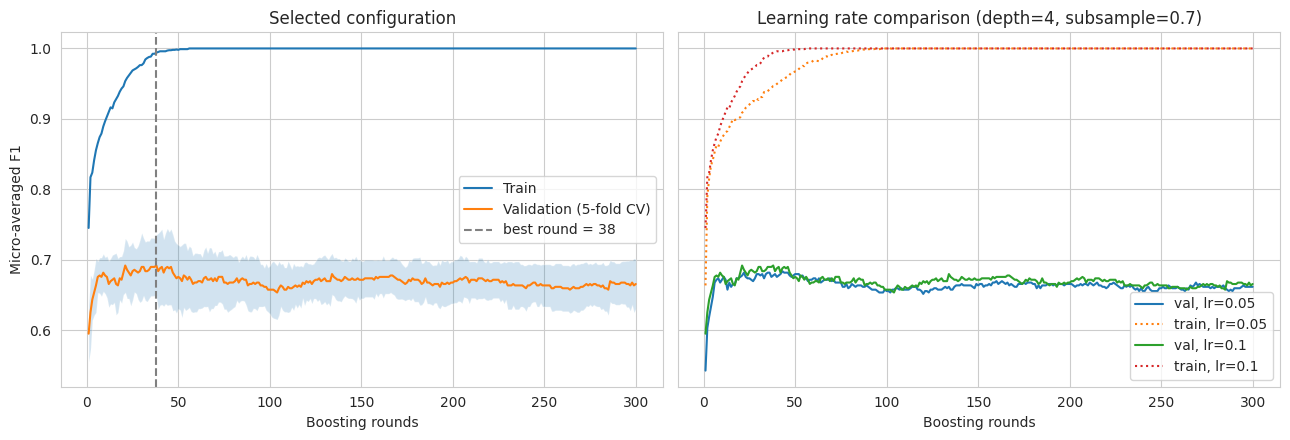

In [7]:
use_all = res_all.val_micro_f1[0] >= res_orig.val_micro_f1[0]
res_sel, curves_sel, bp_sel = (res_all, curves_all, bp_all) if use_all else (res_orig, curves_orig, bp_orig)
rounds = np.arange(1, MAX_ROUNDS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

v_mean, v_std, t_mean = curves_sel[(bp_sel["learning_rate"], bp_sel["max_depth"], bp_sel["subsample"])]
ax = axes[0]
ax.plot(rounds, t_mean, label="Train"); ax.plot(rounds, v_mean, label="Validation (5-fold CV)")
ax.fill_between(rounds, v_mean - v_std, v_mean + v_std, alpha=0.2)
ax.axvline(bp_sel["n_estimators"], ls="--", c="gray", label=f"best round = {bp_sel['n_estimators']}")
ax.set_title("Selected configuration"); ax.set_xlabel("Boosting rounds"); ax.set_ylabel("Micro-averaged F1"); ax.legend()

ax = axes[1]
for lr in GRID["learning_rate"]:
    vm, _, tm = curves_sel[(lr, bp_sel["max_depth"], bp_sel["subsample"])]
    ax.plot(rounds, vm, label=f"val, lr={lr}"); ax.plot(rounds, tm, ls=":", label=f"train, lr={lr}")
ax.set_title(f"Learning rate comparison (depth={bp_sel['max_depth']}, subsample={bp_sel['subsample']})")
ax.set_xlabel("Boosting rounds"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Choose the final model
We pick the variant (original vs. engineered features) with the higher CV micro-F1. The test set is still untouched.

In [8]:
if use_all:
    final_name, X_tr_final, X_te_final, feats = "Tuned GB (+ engineered features)", X_tr_all, X_te_all, ALL_FEATURES
else:
    final_name, X_tr_final, X_te_final, feats = "Tuned GB (orig. features)", X_tr_orig, X_te_orig, ORIG_FEATURES

print("Selected:", final_name)
print("Params:  ", bp_sel)
final_model = GradientBoostingClassifier(random_state=RANDOM_STATE, **bp_sel).fit(X_tr_final, y_tr)
print("Fitted %d rounds on all 496 training rows" % final_model.n_estimators_)

Selected: Tuned GB (orig. features)
Params:   {'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.7, 'n_estimators': 38}


Fitted 38 rounds on all 496 training rows


## 7. Feature importances
**Impurity-based** importance is fast but biased toward continuous features. **Permutation importance** (computed on held-out CV folds) measures how much validation score drops when a feature is shuffled, which is more trustworthy.

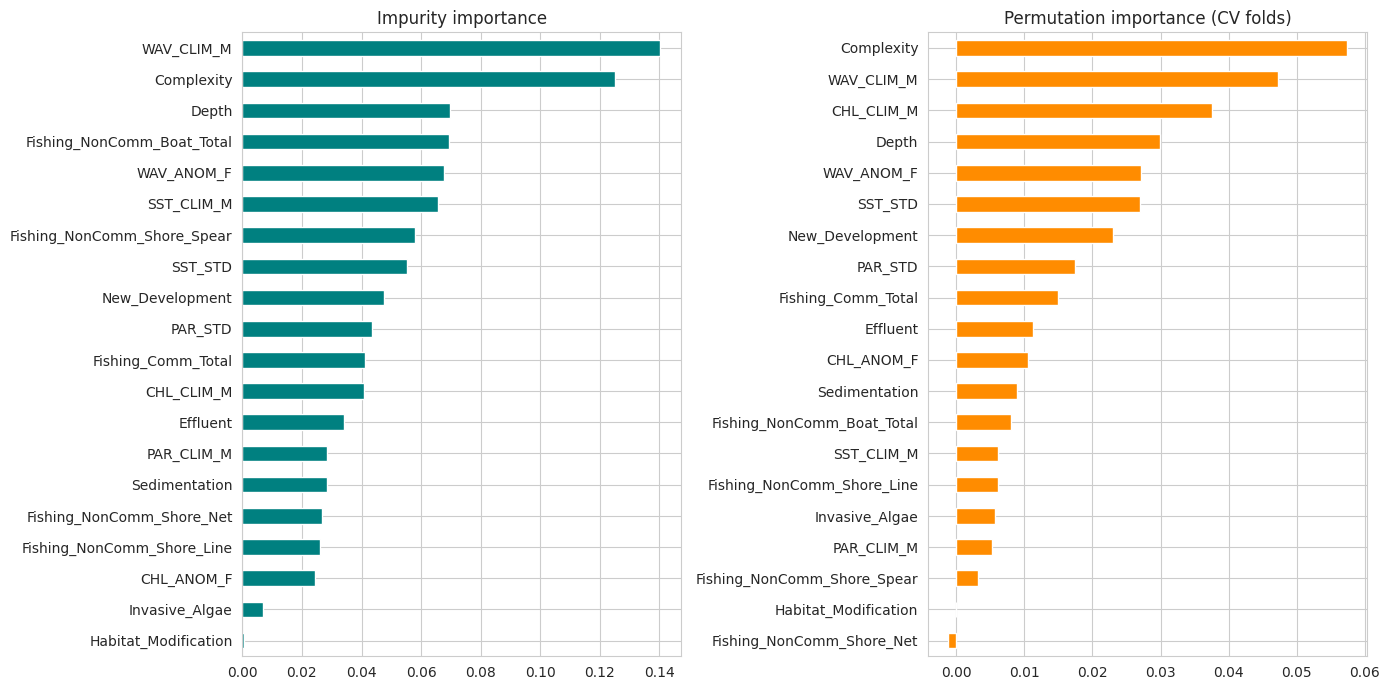

,Impurity,Permutation
Complexity,0.1250,0.0573
WAV_CLIM_M,0.1402,0.0473
CHL_CLIM_M,0.0410,0.0376
Depth,0.0697,0.0299
WAV_ANOM_F,0.0678,0.0271
SST_STD,0.0553,0.0271
New_Development,0.0475,0.0230
PAR_STD,0.0435,0.0174
Fishing_Comm_Total,0.0413,0.0149
Effluent,0.0342,0.0113


In [9]:
imp_gini = pd.Series(final_model.feature_importances_, index=feats)

perm = np.zeros(len(feats))
for tr_idx, va_idx in cv.split(X_tr_final, y_tr):
    m = GradientBoostingClassifier(random_state=RANDOM_STATE, **bp_sel).fit(X_tr_final.iloc[tr_idx], y_tr.iloc[tr_idx])
    pi = permutation_importance(m, X_tr_final.iloc[va_idx], y_tr.iloc[va_idx],
                                scoring="f1_micro", n_repeats=5, random_state=RANDOM_STATE)
    perm += pi.importances_mean / cv.get_n_splits()
imp_perm = pd.Series(perm, index=feats)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, s, title, col in [(axes[0], imp_gini, "Impurity importance", "teal"),
                          (axes[1], imp_perm, "Permutation importance (CV folds)", "darkorange")]:
    s.sort_values().plot.barh(ax=ax, color=col); ax.set_title(title)
plt.tight_layout(); plt.show()

pd.DataFrame({"Impurity": imp_gini, "Permutation": imp_perm}).sort_values("Permutation", ascending=False).head(10).round(4)

## 8. Final evaluation on the held-out test set (n = 124)
The test set is used **once**, with the model chosen from CV alone.

Test micro-F1 : 0.710
Test macro-F1 : 0.693
Test accuracy : 0.710   (identical to micro-F1 for single-label multiclass)

Per-class report:
              precision    recall  f1-score   support

       Reg 1      0.791     0.773     0.782        44
       Reg 2      0.750     0.649     0.696        37
       Reg 3      0.643     0.720     0.679        25
       Reg 5      0.571     0.667     0.615        18

    accuracy                          0.710       124
   macro avg      0.689     0.702     0.693       124
weighted avg      0.717     0.710     0.711       124



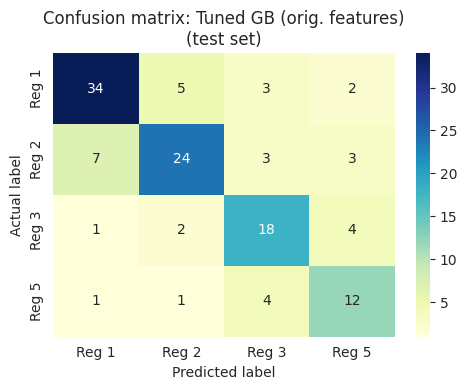

In [10]:
test_pred = final_model.predict(X_te_final)
print("Test micro-F1 : %.3f" % f1_score(y_te, test_pred, average="micro"))
print("Test macro-F1 : %.3f" % f1_score(y_te, test_pred, average="macro"))
print("Test accuracy : %.3f   (identical to micro-F1 for single-label multiclass)" % accuracy_score(y_te, test_pred))
print("\nPer-class report:")
print(classification_report(y_te, test_pred, target_names=CLASS_NAMES, digits=3))
plot_cm(y_te, test_pred, f"Confusion matrix: {final_name}\n(test set)")

## 9. Error analysis and calibration

In [11]:
cm = confusion_matrix(y_te, test_pred, labels=[1, 2, 3, 5])
recalls = recall_score(y_te, test_pred, average=None, labels=[1, 2, 3, 5])
print("Per-class recall:", {k: round(float(v), 3) for k, v in zip(CLASS_NAMES, recalls)})

errs = sorted([(CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j])) for i in range(4) for j in range(4) if i != j and cm[i, j]],
              key=lambda t: -t[2])
print("\nMost common confusions (actual -> predicted):")
for a, p, n in errs[:5]:
    print(f"  {a} -> {p}: {n}")

proba = final_model.predict_proba(X_te_final)
conf = proba.max(axis=1)
correct = (final_model.classes_[proba.argmax(axis=1)] == y_te.values)
bins = pd.cut(conf, bins=[0, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0])
cal = pd.DataFrame({"conf": conf, "correct": correct, "bin": bins}).groupby("bin", observed=True).agg(
    n=("correct", "size"), accuracy=("correct", "mean"), mean_conf=("conf", "mean")).round(3)
print("\nAccuracy by confidence bucket (test set):")
print(cal)

Per-class recall: {'Reg 1': 0.773, 'Reg 2': 0.649, 'Reg 3': 0.72, 'Reg 5': 0.667}

Most common confusions (actual -> predicted):
  Reg 2 -> Reg 1: 7
  Reg 1 -> Reg 2: 5
  Reg 3 -> Reg 5: 4
  Reg 5 -> Reg 3: 4
  Reg 1 -> Reg 3: 3

Accuracy by confidence bucket (test set):
             n  accuracy  mean_conf
bin                                
(0.0, 0.4]   6     0.333      0.384
(0.4, 0.5]   7     0.571      0.420
(0.5, 0.6]  13     0.615      0.554
(0.6, 0.7]  11     0.455      0.653
(0.7, 0.8]  18     0.611      0.749
(0.8, 1.0]  69     0.841      0.899


## 10. Summary against the paper and the other models

In [12]:
summary = comparison.copy()
summary.loc[len(summary)] = ["FINAL: " + final_name + " (test set)", np.nan,
                             f1_score(y_te, test_pred, average="micro"), np.nan,
                             f1_score(y_te, test_pred, average="macro")]
display(summary.round(3))
print("Paper's Gradient Boosted Trees (+ engineered features): train 0.83 | val 0.69")
print("Paper's Random Forest (+ engineered features):          train 1.00 | val 0.70 | test 0.70")

,Model,Train micro-F1,Val micro-F1,Val std,Val macro-F1
0,Default GB (orig. features),1.000,0.641,0.043,0.639
1,Default GB (+ engineered features),1.000,0.649,0.031,0.646
2,Tuned GB (orig. features),0.994,0.692,0.044,0.690
3,Tuned GB (+ engineered features),1.000,0.681,0.032,0.679
4,FINAL: Tuned GB (orig. features) (test set),NaN,0.710,NaN,0.693


Paper's Gradient Boosted Trees (+ engineered features): train 0.83 | val 0.69
Paper's Random Forest (+ engineered features):          train 1.00 | val 0.70 | test 0.70


### Notes
- **Boosting vs. forests:** boosting fits trees sequentially to the previous errors (bias reduction), while a forest averages independent deep trees (variance reduction). On small, noisy data like this, boosting tends to overfit unless `learning_rate`, depth and `subsample` are kept conservative. The learning-curve plot in section 5 shows this directly.
- **Noise:** with 496 training rows and 124 test rows, one test point is about 0.8 F1 points. Differences of 1-3 points between models, or between this run and the paper, are not meaningful.
- **This completes the five-model set:** Logistic Regression (1), SVM (2), Decision Tree (3), Random Forest (4), Gradient Boosting (5).